In [1]:
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts')

sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts/mge_classv2')
from mge_gen3 import MGEFitter
from astropy.io import fits
import numpy as np
import mgefit as mge
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [2]:
    
def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value',
              ax=None, show=True, vmin=None, vmax=None, cbar=True):
    # takes the xy and values and plots as an image with a colorbar
    # create a grid of x and y values
    xi = np.linspace(np.min(x), np.max(x), 100)
    yi = np.linspace(np.min(y), np.max(y), 100)
    xi, yi = np.meshgrid(xi, yi)
    # interpolate the values onto the grid
    zi = griddata((x, y), values, (xi, yi), method='cubic')
    # plot the image
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)),
                    origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    if cbar:
        plt.colorbar(im, ax=ax, label=cbar_label, pad=0.01)
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    if show:
        plt.show()

In [3]:
# open sinfoni coadd
sinfoni_hdu = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/sinfoni/M104_coadded_SINFONI(1).fits')

In [16]:
hdr = sinfoni_hdu[0].header
hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   84                                                  
NAXIS2  =                   84                                                  
NAXIS3  =                 1837                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2024-10-23T13:41:47' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
MJD-OBS =       56738.28881875 / Obs start 2014-03-22T06:55:53.940              
INSTRUME= 'SINFONI '           / Instrument used.                               
ORIGIN  = 'ESO-PARANAL'        / European Southern Observatory                  
TELESCOP= 'ESO-VLT-U4'      

In [52]:
# plot the spectra in the central pixels
data = sinfoni_hdu[0].data
print(data.shape)
example_spaxel = data[:, 40, 40]

# extract wavelength grid from header
reference_pixel = hdr['CRPIX3']
central_wvlg = hdr['CRVAL3']
microns_per_pixel = hdr['CDELT3']

# we have 1837 pixels with microns_per_pixel spacing where we know the value of the reference pixel in um
first_wvlng = central_wvlg - reference_pixel*microns_per_pixel # init wavelength in um
final_wvlng = first_wvlng + data.shape[0]*microns_per_pixel
wavelength_grid = np.arange(first_wvlng,final_wvlng, microns_per_pixel )

(1837, 84, 84)


<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_35672/2421356133.py:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('Wavelength $\mu$m')


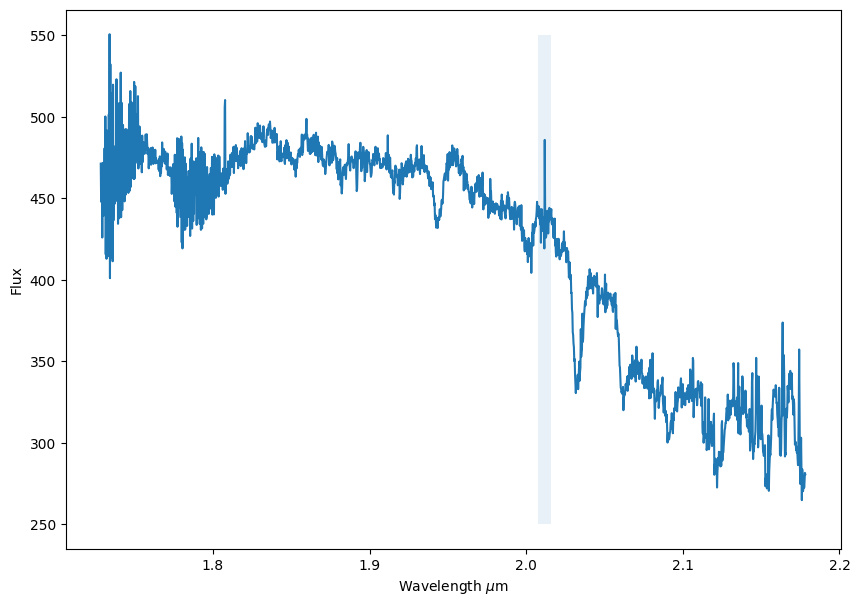

In [72]:
fig, ax = plt.subplots(1,1, figsize = (10, 7))
ax.plot(wavelength_grid, example_spaxel)
# shaded grey region for the masked range 2.117-2.127
ax.fill_between(x=[2.0077,2.0157], y1=250, y2=550 , alpha= 0.1)
ax.set_xlabel('Wavelength $\mu$m')
ax.set_ylabel('Flux')
plt.show()